In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

In [2]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

urls = [
    "https://langchain-ai.github.io/langgraph/tutorials/introduction/",
    "https://langchain-ai.github.io/langgraph/tutorials/workflows/",
    "https://langchain-ai.github.io/langgraph/how-tos/map-reduce/"
]

docs = [WebBaseLoader(url).load() for url in urls]
docs_list = [item for sublist in docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000,chunk_overlap=200)
doc_splits = text_splitter.split_documents(docs_list)

## Add all this text to vectordb
vectorstore = FAISS.from_documents(
    documents = doc_splits,
    embedding = OpenAIEmbeddings()
)


USER_AGENT environment variable not set, consider setting it to identify your requests.


In [3]:
retriever = vectorstore.as_retriever()

In [4]:
retriever.invoke("what is langgraph")

[Document(id='39668bc8-4091-49ae-a56b-3733bd984b8d', metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/introduction/', 'title': 'Learn the basics', 'description': 'Build language agents as graphs', 'language': 'en'}, page_content="Assistant: LangGraph is a library designed to help build stateful multi-agent applications using language models. It provides tools for creating workflows and state machines to coordinate multiple AI agents or language model interactions. LangGraph is built on top of LangChain, leveraging its components while adding graph-based coordination capabilities. It's particularly useful for developing more complex, stateful AI applications that go beyond simple query-response interactions.\nGoodbye!"),
 Document(id='497fc69c-ebaf-4825-ae73-caa3e39d5e58', metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/introduction/', 'title': 'Learn the basics', 'description': 'Build language agents as graphs', 'language': 'en'}, page_con

In [5]:
from langchain.tools.retriever import create_retriever_tool

retriever_tool = create_retriever_tool(retriever,
                                       "retriever_vector_db_blog",
                                       "search and run information about langgraph")

In [6]:
retriever_tool

Tool(name='retriever_vector_db_blog', description='search and run information about langgraph', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=functools.partial(<function _get_relevant_documents at 0x000001D0A97D6DE0>, retriever=VectorStoreRetriever(tags=['FAISS', 'OpenAIEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x000001D0ACDCA900>, search_kwargs={}), document_prompt=PromptTemplate(input_variables=['page_content'], input_types={}, partial_variables={}, template='{page_content}'), document_separator='\n\n', response_format='content'), coroutine=functools.partial(<function _aget_relevant_documents at 0x000001D0A98DC7C0>, retriever=VectorStoreRetriever(tags=['FAISS', 'OpenAIEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x000001D0ACDCA900>, search_kwargs={}), document_prompt=PromptTemplate(input_variables=['page_content'], input_types={}, partial_variables={}, template='{page_content}'), 

In [7]:
from typing import Annotated,Sequence,Literal
from typing_extensions import TypedDict 

from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage],add_messages]
    

In [8]:
from langchain_groq import ChatGroq
tools = [retriever_tool]


In [9]:
def agent(state:AgentState):
    """ 
    Invokes the agent model to generate a response based on the current state.Given the question,
    It will decide to retrieve using a retriever tool,or simply end.
 
    Args:
     state (messages) : The current state.

    Returns:
     dict: The updated state with the agent response appended to messages.
    
    """
    print("--- CALL AGENT---")
    messages = state["messages"] 
    model = ChatGroq(model_name="qwen-2.5-32b")
    model = model.bind_tools(tools)
    response = model.invoke(messages)

    return {"messages": [response]}


In [10]:
from langchain import hub 
from langchain_core.messages import BaseMessage,HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate 
from langchain_openai import ChatOpenAI
from pydantic import BaseModel,Field

In [11]:
def grade_documents(state:AgentState)->Literal["rewrite","generate"]:
    """ 
    Determines whether the retrieved documents relevant to the question.

    Args:
      state (messages): The current state

    Returns:
      str: A decision for whether the documents are relevant or not.
    """
    print("---CHECK RELEVANCE---")

    class grade(BaseModel):
        """Binary score for relevance check"""
        binary_score: str = Field(description="Relevance score 'yes' or 'no'")

    # Model
    llm = ChatGroq(model_name="qwen-2.5-32b")
    # LLM with tool and validation
    llm_with_tool = llm.with_structured_output(grade)

    #prompt
    prompt = PromptTemplate(
        template="""You are a grader assessing relevance of a retrieved document to a user question. \n 
        Here is the retrieved document: \n\n {context} \n\n
        Here is the user question: {question} \n
        If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
        Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.""",
        input_variables=["context", "question"],
    )

    chain = prompt | llm_with_tool 

    messages = state["messages"]
    last_message = messages[-1]

    question = messages[0].content 
    docs = last_message.content 

    scored_result = chain.invoke({"question":question,"context":docs})
    score = scored_result.binary_score 

    if score == 'yes':
        print("---DECISION: DOCS RELEVANT")
        return "generate"
    else:
        print("---DECISION: DOCS NOT RELEVANT")
        print(score)
        return "rewrite"
    
    



In [12]:
def generate(state: AgentState):
    """ 
    Generate answer
   
    Args:
       state (messages): The current state

    Returns
      dict: The updated message

    """
    print("--GENERATE--")
    messages = state["messages"]
    print("messages:  ",messages)
    question = messages[0].content 
    last_message = messages[-1]
    docs = last_message.content 
    

    #prompt 
    prompt = hub.pull("rlm/rag-prompt")

    # LLM
    llm = ChatGroq(model= "qwen-2.5-32b")

    #Post-processing
    def format_docs(docs):
        return "\n\n".join([doc for doc in docs])
    
    docs = format_docs(docs)
    # chain
    rag_chain = prompt | llm | StrOutputParser()

    response = rag_chain.invoke({"context": docs,"question":question})
    return {"messages": [response]}

In [13]:
print("*" * 20 + "Prompt[rlm/rag-prompt]" + "*" * 20)
prompt = hub.pull("rlm/rag-prompt").pretty_print()  # 

********************Prompt[rlm/rag-prompt]********************
================================ Human Message =================================

You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.
Question: {question} 
Context: {context} 
Answer:


In [14]:
def rewrite(state:AgentState):
    """ 
    Transform the query to produce a better question

    Args:
       state (messages): the current state

    returns
      dict: The updated state with re-phrased question
    
    """
    print("--- TRANSFORM QUERY---")

    messages = state["messages"]
    question = messages[0].content

    msg = [
            HumanMessage(
                content=f""" \n 
        Look at the input and try to reason about the underlying semantic intent / meaning. \n 
        Here is the initial question:
        \n ------- \n
        {question} 
        \n ------- \n
        Formulate an improved question: """,
            )
        ]
    
    model = ChatGroq(model="qwen-2.5-32b")
    response = model.invoke(msg)
    return {"messages":[response]}

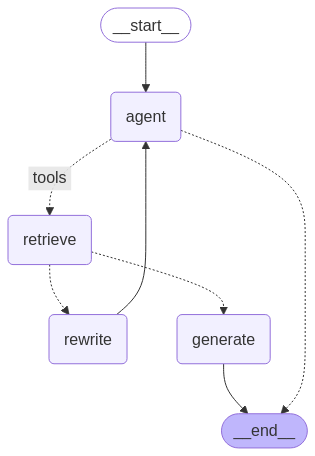

In [15]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from IPython.display import Image,display
# Define a new Graph
workflow = StateGraph(AgentState)

workflow.add_node("agent",agent)
workflow.add_node("retrieve",ToolNode(tools))
workflow.add_node("rewrite",rewrite)
workflow.add_node("generate",generate)

workflow.add_edge(START,"agent") 
workflow.add_conditional_edges(
    "agent",
    tools_condition,
    {
        "tools":"retrieve",
        END:END
    }
)

workflow.add_conditional_edges(
    "retrieve",
    grade_documents
)

workflow.add_edge("rewrite","agent") 
workflow.add_edge("generate",END)

graph = workflow.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [16]:
graph.invoke({"messages":"what is langgraph"})

--- CALL AGENT---
---CHECK RELEVANCE---
---DECISION: DOCS RELEVANT
--GENERATE--
messages:   [HumanMessage(content='what is langgraph', additional_kwargs={}, response_metadata={}, id='d548ce80-2d42-4c05-ac0f-3aa3bf7b6dc8'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_xeyg', 'function': {'arguments': '{"query": "langgraph"}', 'name': 'retriever_vector_db_blog'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 183, 'total_tokens': 208, 'completion_time': 0.125, 'prompt_time': 0.012217976, 'queue_time': 0.236433258, 'total_time': 0.137217976}, 'model_name': 'qwen-2.5-32b', 'system_fingerprint': 'fp_35f92f8282', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-180492c7-9467-423e-8641-516bb67e95f5-0', tool_calls=[{'name': 'retriever_vector_db_blog', 'args': {'query': 'langgraph'}, 'id': 'call_xeyg', 'type': 'tool_call'}], usage_metadata={'input_tokens': 183, 'output_tokens': 25, 'total_tokens': 208}), ToolM

{'messages': [HumanMessage(content='what is langgraph', additional_kwargs={}, response_metadata={}, id='d548ce80-2d42-4c05-ac0f-3aa3bf7b6dc8'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_xeyg', 'function': {'arguments': '{"query": "langgraph"}', 'name': 'retriever_vector_db_blog'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 183, 'total_tokens': 208, 'completion_time': 0.125, 'prompt_time': 0.012217976, 'queue_time': 0.236433258, 'total_time': 0.137217976}, 'model_name': 'qwen-2.5-32b', 'system_fingerprint': 'fp_35f92f8282', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-180492c7-9467-423e-8641-516bb67e95f5-0', tool_calls=[{'name': 'retriever_vector_db_blog', 'args': {'query': 'langgraph'}, 'id': 'call_xeyg', 'type': 'tool_call'}], usage_metadata={'input_tokens': 183, 'output_tokens': 25, 'total_tokens': 208}),
  ToolMessage(content='Assistant: LangGraph is a library designed to help build st

In [17]:
graph.invoke({"messages":"what is Machine learning"})

--- CALL AGENT---


{'messages': [HumanMessage(content='what is Machine learning', additional_kwargs={}, response_metadata={}, id='191082fb-250f-4f98-b3be-02a894726e4d'),
  AIMessage(content='Machine learning is a method of teaching computers to learn from data, without being explicitly programmed. It involves the development of algorithms that can receive input data and use statistical analysis to predict an output while updating outputs as new data becomes available. The process of learning begins with observations or data, such as examples, direct experience, or instruction, to look for patterns in data and make better decisions in the future based on the examples that we provide. The primary aim is to allow the computers to learn automatically without human intervention or assistance and adjust actions accordingly. Machine learning is a subset of artificial intelligence (AI) and has applications in various fields like healthcare, finance, automotive, and more. \n\nWould you like to know more about a s

In [18]:
input = {"messages": "What is prompt chaining in Agentic AI"}

for output in graph.stream(input):
    print(output)

--- CALL AGENT---
{'agent': {'messages': [AIMessage(content='The concept of "prompt chaining" in Agentic AI refers to a technique where multiple prompts are used sequentially to guide an AI through a series of tasks or to build upon previous responses to create a more complex output. This method can help in elaborating on initial ideas, refining responses, or even solving multi-step problems by breaking them down into manageable parts. However, it seems you might be looking for more specific details or examples related to Agentic AI. Could you provide more context or specify if you\'re interested in a particular aspect of Agentic AI and prompt chaining? \n\nIf you are looking for technical details or a specific implementation, and if Agentic AI is related to a particular technology or framework that involves a retriever or a vector database, we might need to look that up. Do you want me to search for more specific information related to Agentic AI and prompt chaining using available re